## Hit probability by genre

**Question:** Does a song's genre affect its chance of becoming a hit?

**Method:** We fit a logistic regression of `is_hit` (1 = song in the top 10% of 3-year streams) on genre, with pop as the reference category.

**Result:** Hit probabilities are roughly equal across genres, all close to the overall rate of about 10% (between roughly 9% and 10.5%), and the confidence intervals overlap strongly. Genre alone does not meaningfully predict whether a song becomes a hit, which motivates looking at other factors such as label, marketing and artist reach.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Load data: find the dataset next to the notebook, in Colab's /content, on Google Drive or on the Mac
candidates = [
    Path("raw-data/song_longevity.csv"),
    Path("song_longevity.csv"),
    Path("song_longevity(1).csv"),
    Path("/content/song_longevity.csv"),
    Path("/content/drive/MyDrive/song_longevity.csv"),
    Path("/mnt/data/song_longevity.csv"),
    Path("/Users/jakobbaiz/Documents/AI_in_Society/Group_project/song_longevity.csv"),
]

data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find song_longevity.csv. Upload it to the notebook's folder "
                            "(Colab: file panel on the left) or mount Google Drive.")

df = pd.read_csv(data_path)
path = str(data_path.parent) + "/"   # output folder: figures are saved next to the data

print("Dataset loaded:", data_path, df.shape)

Dataset loaded: raw-data/song_longevity.csv (45000, 21)


## The start of the analysis



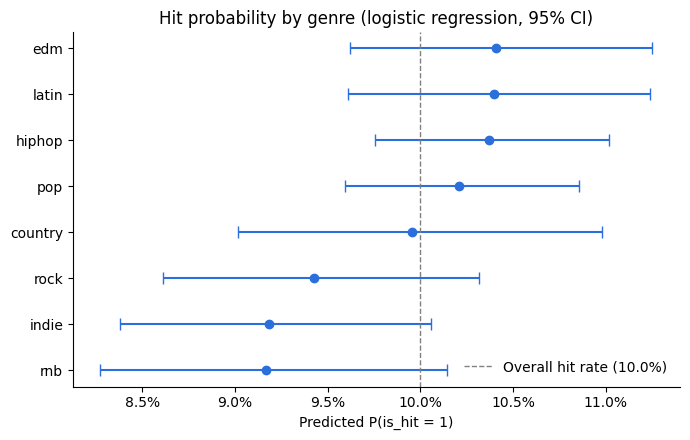

In [2]:
# Fit logistic regression and predict P(hit) per genre with 95% CI
model = smf.logit("is_hit ~ C(genre, Treatment(reference='pop'))", data=df).fit(disp=0)
genres = pd.DataFrame({"genre": sorted(df.genre.unique())})
pred = model.get_prediction(genres).summary_frame()
genres[["p_hit", "ci_low", "ci_high"]] = pred[["predicted", "ci_lower", "ci_upper"]].values
genres = genres.sort_values("p_hit")

# Plot
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(genres.p_hit, genres.genre,
            xerr=[genres.p_hit - genres.ci_low, genres.ci_high - genres.p_hit],
            fmt="o", color="#2a6fdb", capsize=4)
ax.axvline(df.is_hit.mean(), color="grey", ls="--", lw=1,
           label=f"Overall hit rate ({df.is_hit.mean():.1%})")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.set_xlabel("Predicted P(is_hit = 1)")
ax.set_title("Hit probability by genre (logistic regression, 95% CI)")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(path + "hit_prob_by_genre.png", dpi=150)
plt.show()

# This shows that the probability of a song being a hit is roughly equal across genres.

## Marketing budget and 3-year streams

**Question:** Do songs with a higher marketing budget get more streams?

**Method:** We regress log(streams after 3 years) on the marketing budget using OLS with robust (HC3) standard errors. Model (1) has no controls. Model (2) controls for genre, label tier and the artist's prior monthly listeners (logged), since bigger labels and more established artists tend to have both larger budgets and more streams. Because the outcome is in logs, a coefficient β means roughly a 100·(e^β − 1)% change in streams per additional unit of budget.

**Result:** Marketing is strongly and significantly associated with streams. Without controls, one more unit of budget goes along with about 44% more streams (β = 0.367). With controls, the effect drops to about 33% (β = 0.286), so part of the raw association reflects label and artist size. These are associations rather than causal effects, since budgets are likely allocated to songs that are already expected to succeed.

=== Model 1: no controls ===
                            OLS Regression Results                            
Dep. Variable:            log_streams   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     2120.
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        12:52:15   Log-Likelihood:                -96039.
No. Observations:               45000   AIC:                         1.921e+05
Df Residuals:                   44998   BIC:                         1.921e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept  

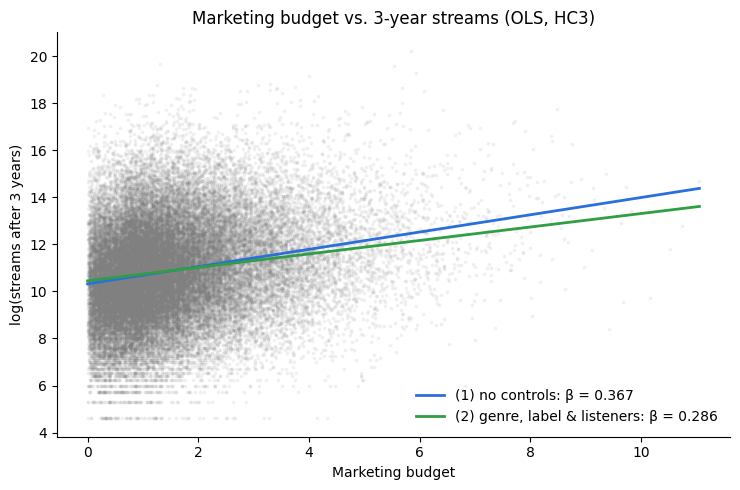

In [3]:
# Relationship between streams and marketing budget
df["log_streams"] = np.log(df.streams_3yr)                        # right-skewed, no zeros
df["log_listeners"] = np.log(df.artist_prior_monthly_listeners)   # right-skewed, min = 100

GENRE = "C(genre, Treatment(reference='pop'))"
LABEL = "C(label_tier, Treatment(reference='independent'))"

# OLS with heteroskedasticity-robust (HC3) standard errors
m1 = smf.ols("log_streams ~ marketing_budget", data=df).fit(cov_type="HC3")
m2 = smf.ols(f"log_streams ~ marketing_budget + {GENRE} + {LABEL} + log_listeners",
             data=df).fit(cov_type="HC3")

print("=== Model 1: no controls ===")
print(m1.summary())
print("\n=== Model 2: genre + label tier + log(prior monthly listeners) ===")
print(m2.summary())

# Comparison of the marketing coefficient
rows = []
for name, m in [("(1) no controls", m1), ("(2) genre, label & listeners", m2)]:
    b, (lo, hi) = m.params["marketing_budget"], m.conf_int().loc["marketing_budget"]
    rows.append({"model": name, "coef": b, "CI_low": lo, "CI_high": hi,
                 "p": m.pvalues["marketing_budget"], "%-effect per unit": 100 * (np.exp(b) - 1),
                 "R2": m.rsquared, "N": int(m.nobs)})
print("\n=== marketing_budget: comparison ===")
print(pd.DataFrame(rows).round(4).to_string(index=False))

# Plot: data + fitted lines (model 2 averaged over the sample's covariates)
grid = np.linspace(df.marketing_budget.min(), df.marketing_budget.max(), 100)
fit1 = m1.predict(pd.DataFrame({"marketing_budget": grid}))
fit2 = np.array([m2.predict(df.assign(marketing_budget=x)).mean() for x in grid])

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(df.marketing_budget, df.log_streams, s=3, alpha=0.08, color="grey", rasterized=True)
ax.plot(grid, fit1, color="#2a6fdb", lw=2,
        label=f"(1) no controls: β = {m1.params['marketing_budget']:.3f}")
ax.plot(grid, fit2, color="#2f9e44", lw=2,
        label=f"(2) genre, label & listeners: β = {m2.params['marketing_budget']:.3f}")
ax.set_xlabel("Marketing budget")
ax.set_ylabel("log(streams after 3 years)")
ax.set_title("Marketing budget vs. 3-year streams (OLS, HC3)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(path + "streams_vs_marketing.png", dpi=150)
plt.show()

## Does the marketing effect differ by label tier or genre?

**Question:** Does an additional unit of marketing budget pay off equally for all songs, or does its effect depend on the label tier or the genre?

**Method:** Building on the controlled model (2), we add interaction terms between marketing budget and label tier (model 3) and between marketing budget and genre (model 4). In these models, the "Marketing budget" coefficient is the slope for the reference group (independent artists or pop), and each interaction term shows how much the slope differs for another group. A joint Wald test checks whether the slopes differ across groups at all. All models use OLS on log(streams after 3 years) with robust (HC3) standard errors.



**Controls:** A variable is included as a control if it plausibly affects both the marketing budget and streams through channels other than marketing; omitting it would bias the marketing coefficient.

* **Label tier:** Labels with more resources spend more on marketing and also generate more streams through other channels (distribution, playlist pitching, catalogue reach). Without this control, the marketing coefficient would partly capture the label effect and overstate the return to marketing. In model (3), label tier additionally serves as the moderator whose slopes we compare.
* **Prior monthly listeners (log):** Established artists receive larger marketing budgets and also have an existing fan base that streams new releases regardless of marketing. Omitting it would again overstate the marketing effect. Because it is measured before release, it cannot itself be affected by the song's marketing.
* **Genre:** Genres may differ in both typical budgets and audience size, so genre is included as a precaution. In our data it does not confound the marketing effect (the coefficient is unchanged when genre is added). In model (4) it is also needed as the main effect of the interaction.








**Result:** The marketing effect is very similar across groups. For label tier, the slope differences are small (+0.031 for indie labels, −0.013 for majors). The joint test gives p = 0.095, which is at most weak evidence of a difference. For genre, the interactions are clearly insignificant (p = 0.761). R² does not improve over model (2), so marketing appears to work about equally well regardless of label or genre.

In [4]:
from IPython.display import HTML, display

df["log_streams"] = np.log(df.streams_3yr)                        # right-skewed, no zeros
df["log_listeners"] = np.log(df.artist_prior_monthly_listeners)   # right-skewed, min = 100

GENRE = "C(genre, Treatment(reference='pop'))"
LABEL = "C(label_tier, Treatment(reference='independent'))"

# ---------------------------------------------------------------- models (OLS, HC3)
m1_base  = smf.ols("log_streams ~ marketing_budget", data=df).fit(cov_type="HC3")
m2_ctrl  = smf.ols(f"log_streams ~ marketing_budget + {GENRE} + {LABEL} + log_listeners",
                   data=df).fit(cov_type="HC3")
m3_label = smf.ols(f"log_streams ~ marketing_budget * {LABEL} + {GENRE} + log_listeners",
                   data=df).fit(cov_type="HC3")
m4_genre = smf.ols(f"log_streams ~ marketing_budget * {GENRE} + {LABEL} + log_listeners",
                   data=df).fit(cov_type="HC3")

models = {"(1) No controls": m1_base, "(2) Controls": m2_ctrl,
          "(3) × Label tier": m3_label, "(4) × Genre": m4_genre}

# ---------------------------------------------------------------- rows shown in the table
genres = sorted(g for g in df.genre.unique() if g != "pop")
labels = ["indie_label", "major"]
terms = (["marketing_budget"]
         + [f"{LABEL}[T.{l}]" for l in labels]
         + ["log_listeners"]
         + [f"marketing_budget:{LABEL}[T.{l}]" for l in labels]
         + [f"marketing_budget:{GENRE}[T.{g}]" for g in genres]
         + ["Intercept"])

nice = {"marketing_budget": "Marketing budget", "log_listeners": "log(prior monthly listeners)",
        "Intercept": "Constant"}
nice |= {f"{LABEL}[T.{l}]": f"Label: {l}" for l in labels}
nice |= {f"marketing_budget:{LABEL}[T.{l}]": f"Marketing × label: {l}" for l in labels}
nice |= {f"marketing_budget:{GENRE}[T.{g}]": f"Marketing × genre: {g}" for g in genres}


def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""


def joint_p(m, prefix):
    """p-value of the joint Wald test that all parameters starting with `prefix` are zero."""
    ps = [p for p in m.params.index if p.startswith(prefix)]
    if not ps:
        return None
    return m.wald_test(" = 0, ".join(ps) + " = 0", scalar=True).pvalue


# ---------------------------------------------------------------- build table
index, rows = [], []
for term in terms:
    coef, tval = {}, {}
    for col, m in models.items():
        if term in m.params:
            coef[col] = f"{m.params[term]:.3f}{stars(m.pvalues[term])}"
            tval[col] = f"({m.tvalues[term]:.2f})"
        else:
            coef[col], tval[col] = "", ""
    index += [nice[term], ""]
    rows += [coef, tval]

stats = [
    ("Genre controls", lambda m: "Yes" if any(p.startswith("C(genre") for p in m.params.index) else "No"),
    ("Observations", lambda m: f"{int(m.nobs):,}"),
    ("R²", lambda m: f"{m.rsquared:.3f}"),
    ("Adj. R²", lambda m: f"{m.rsquared_adj:.3f}"),
    ("Wald test interactions (p)",
     lambda m: "" if joint_p(m, "marketing_budget:") is None else f"{joint_p(m, 'marketing_budget:'):.3f}"),
]
for name, f in stats:
    index.append(name)
    rows.append({col: f(m) for col, m in models.items()})

table = pd.DataFrame(rows, index=index)

# joint test of the genre dummies in the controls model, reported in the notes
p_genre = joint_p(m2_ctrl, "C(genre")
print(f"Genre dummies jointly = 0 in model (2): p = {p_genre:.3f}")

# ---------------------------------------------------------------- HTML output
notes = ("Dependent variable: log(streams after 3 years). OLS with heteroskedasticity-robust (HC3) "
         "standard errors; t-statistics in parentheses. * p &lt; 0.10, ** p &lt; 0.05, *** p &lt; 0.01. "
         "Reference categories: pop (genre), independent (label tier). Genre dummies included where "
         f"indicated but not shown (joint Wald test in model (2): p = {p_genre:.3f}). In (3) and (4), "
         "&lsquo;Marketing budget&rsquo; is the slope for the reference group; interaction terms are "
         "slope differences relative to it.")

n_stats = len(stats)
css = f"""
.wrap {{ display: inline-block; font-family: "Times New Roman", Georgia, serif; color: #111;
        background: #fff; padding: 16px; }}
.wrap h3 {{ font-weight: normal; font-size: 16px; margin: 0 0 8px; }}
table.regtable {{ border-collapse: collapse; font-size: 14px; }}
table.regtable thead th {{ border-top: 2px solid #000; border-bottom: 1px solid #000;
                          padding: 6px 14px; font-weight: normal; text-align: center; }}
table.regtable tbody th {{ text-align: left; font-weight: normal; padding: 2px 14px 2px 0; }}
table.regtable td {{ text-align: center; padding: 2px 14px; }}
table.regtable tbody tr:nth-child(even) td {{ font-size: 12px; color: #555; padding-bottom: 6px; }}
table.regtable tbody tr:nth-last-child(-n+{n_stats}) td {{ font-size: 14px; color: #111; padding-bottom: 2px; }}
table.regtable tbody tr:nth-last-child({n_stats}) th,
table.regtable tbody tr:nth-last-child({n_stats}) td {{ border-top: 1px solid #000; padding-top: 6px; }}
table.regtable tbody tr:last-child th,
table.regtable tbody tr:last-child td {{ border-bottom: 2px solid #000; padding-bottom: 6px; }}
.wrap .notes {{ font-size: 12px; max-width: 760px; margin-top: 8px; line-height: 1.4; }}
"""

body = f"""<div class="wrap">
<h3>Table 1: Marketing budget and 3-year streams</h3>
{table.to_html(classes="regtable", border=0)}
<p class="notes"><i>Notes:</i> {notes}</p>
</div>"""

# save as a standalone HTML file and show it in the notebook
with open(path + "regression_table.html", "w", encoding="utf-8") as f:
    f.write(f'<!doctype html><html><head><meta charset="utf-8"><title>Regression table</title>'
            f'<style>{css}</style></head><body>{body}</body></html>')
display(HTML(f"<style>{css}</style>{body}"))

Genre dummies jointly = 0 in model (2): p = 0.193


,(1) No controls,(2) Controls,(3) × Label tier,(4) × Genre
Marketing budget,0.367***,0.286***,0.281***,0.283***
,(46.05),(36.78),(23.85),(16.83)
Label: indie_label,,0.492***,0.449***,0.491***
,,(22.01),(12.97),(22.00)
Label: major,,1.146***,1.175***,1.146***
,,(51.14),(29.29),(51.11)
log(prior monthly listeners),,0.195***,0.195***,0.195***
,,(45.39),(45.40),(45.38)
Marketing × label: indie_label,,,0.031,
,,,(1.63),


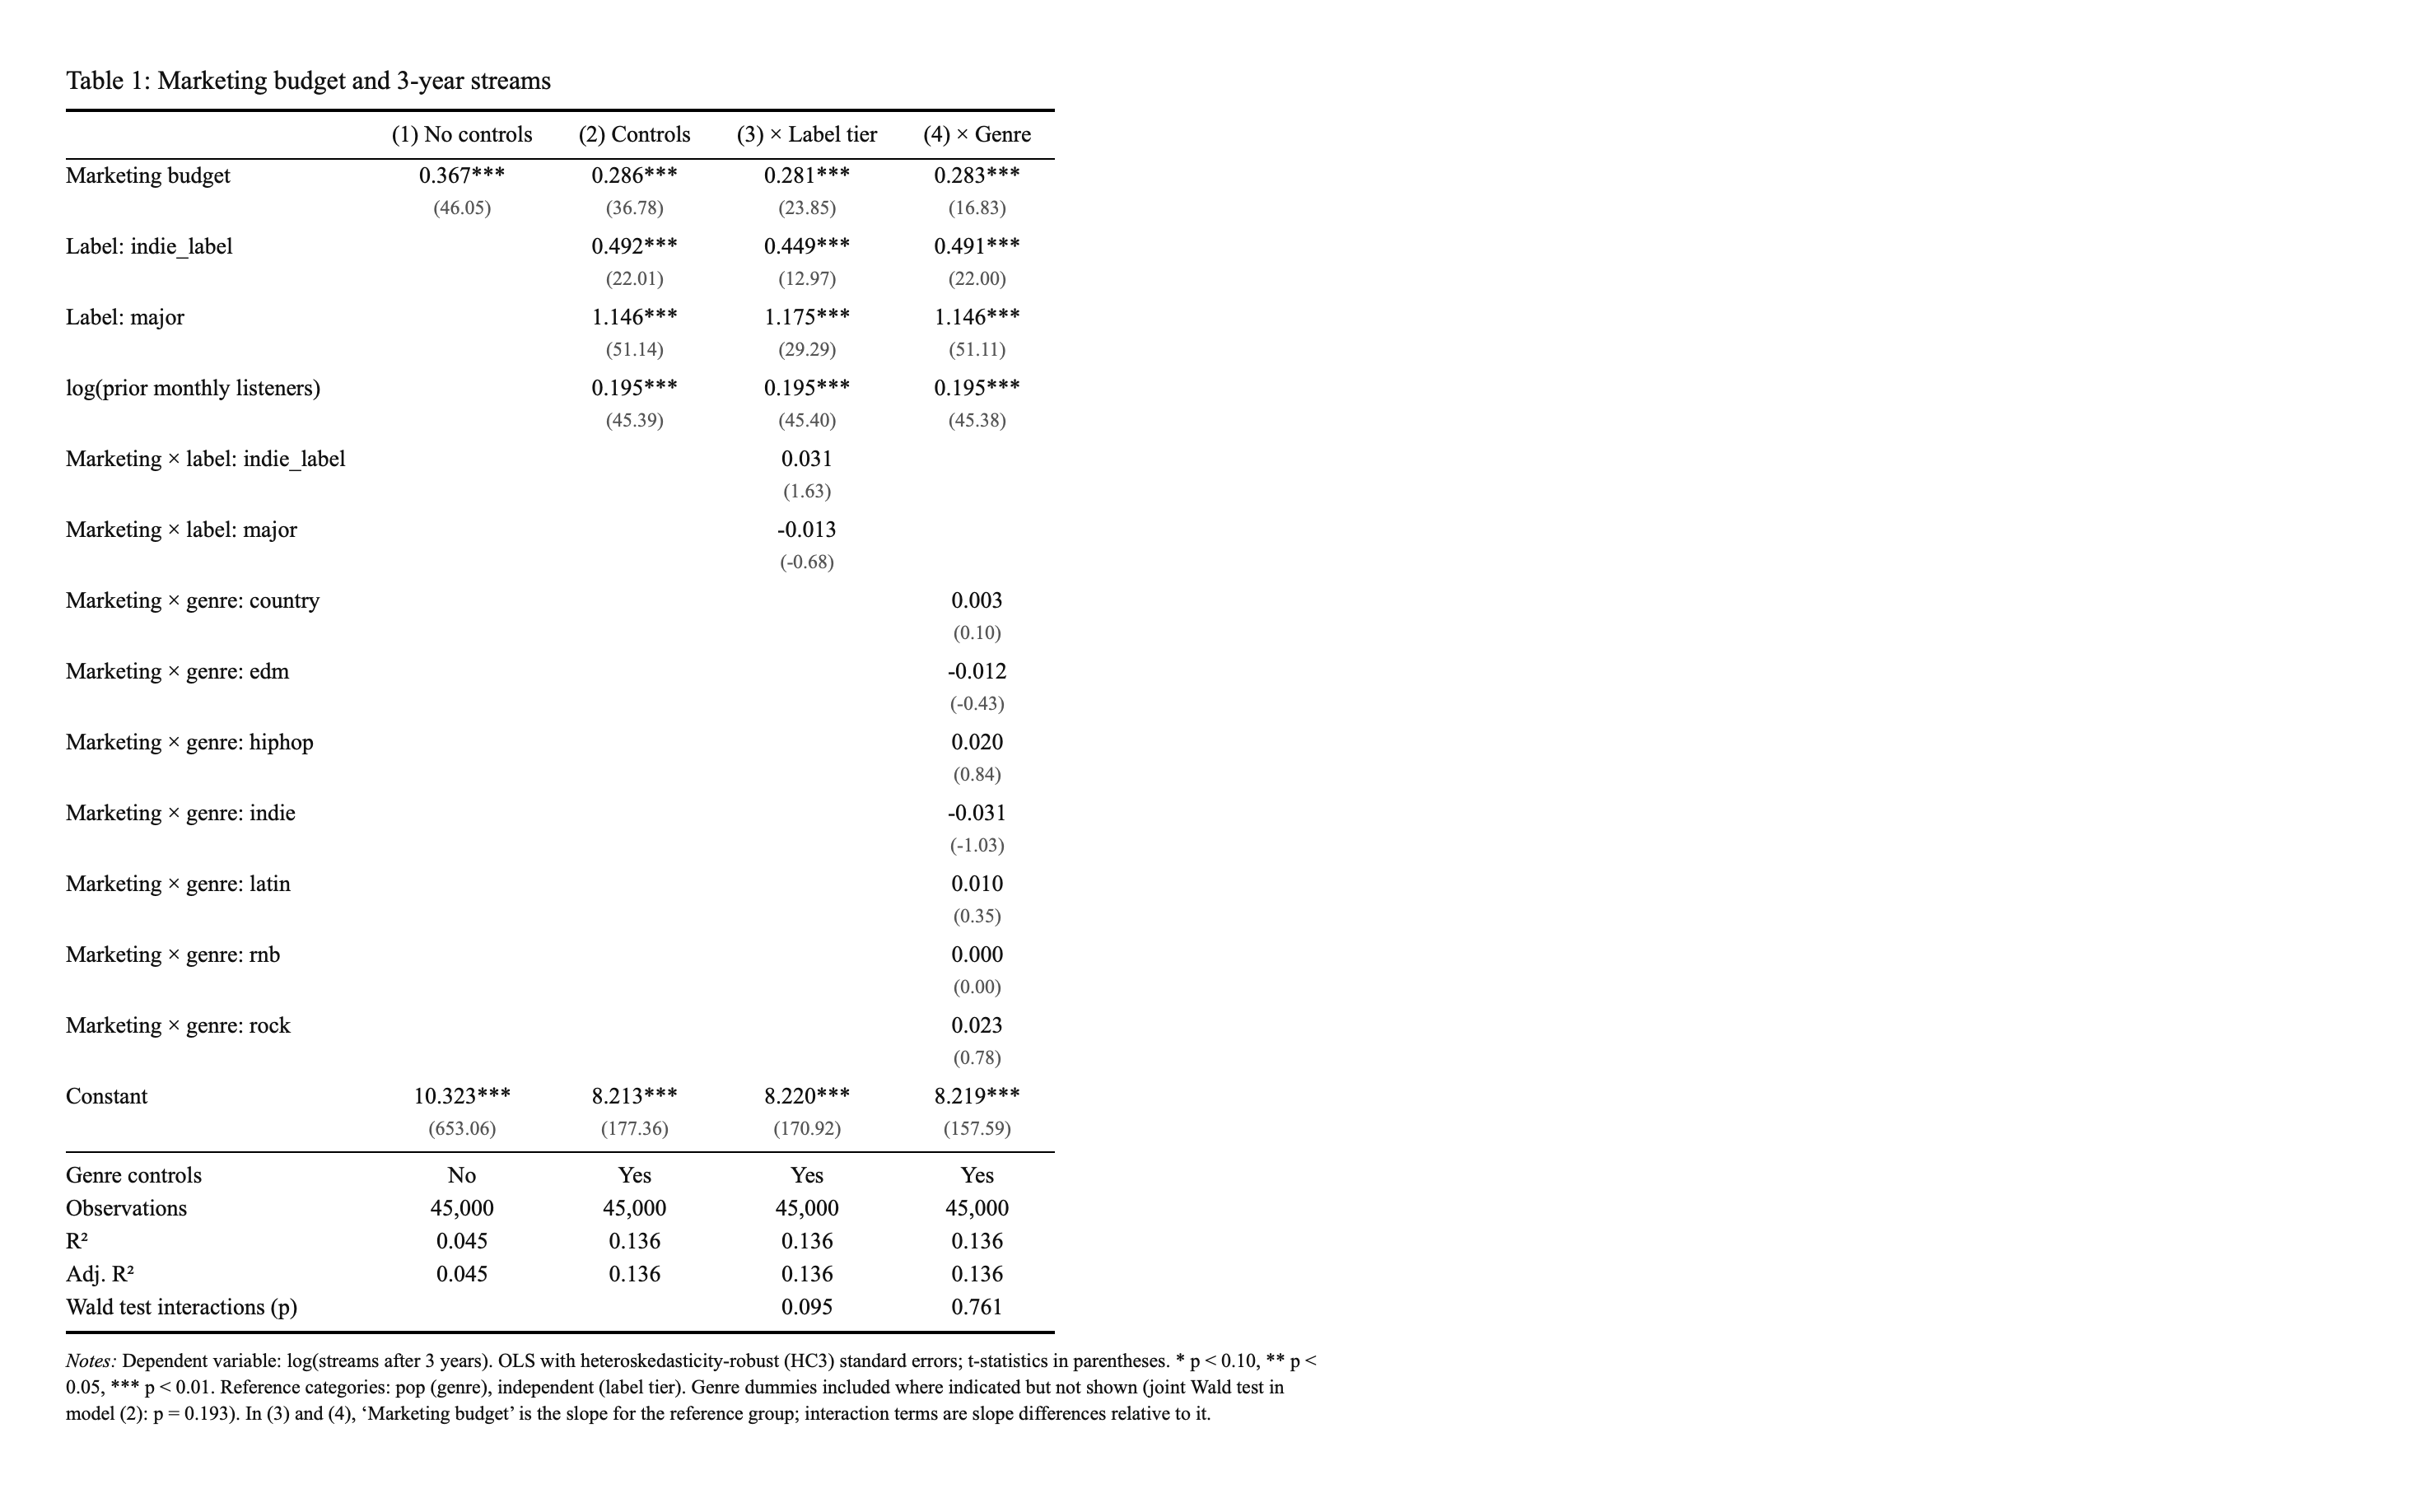

## What drives streams when all variables are considered together?

**Question:** Which factors are associated with a song's long-term streams once we account for all available variables at the same time — and does the marketing effect hold up?

**Method:** We estimate five OLS models of log(streams after 3 years) with robust (HC3) standard errors, adding controls step by step. Model (1) includes only the marketing budget; (2) adds genre fixed effects; (3) adds label tier and the artist's prior monthly listeners (logged); (4) adds TikTok virality; (5) is the full specification, adding a featured-artist dummy and seven standardized audio features (energy, valence, danceability, acousticness, instrumentalness, tempo, song length). Because the outcome is in logs, a coefficient β corresponds to a 100·(e^β − 1)% change in streams.

**Result:** In the full model (5), all main variables are statistically significant at the 1% level:

- **Label tier** is the strongest predictor: major-label songs have roughly 3.2 times the streams of independent releases (+215%), indie-label songs about +63%.
- **TikTok virality**: about +55% streams per unit.
- **Marketing budget**: about +33% streams per unit. The coefficient is stable from model (3) onward (0.286 → 0.283), so it is robust to adding further controls.
- **Featured artist**: songs with a feature have about 27% more streams.
- **Prior monthly listeners**: an elasticity of about 0.2, i.e. doubling an artist's prior audience goes along with about 15% more streams.

Genre adds no explanatory power (R² 0.045 → 0.046), and the audio features add very little (0.251 → 0.257).

With R² = 0.257, the model explains about a quarter of the variation in streams, which is reasonable for song-level data, where quality, timing and luck play a large role. TikTok virality adds the most explanatory power (R² rises from 0.136 to 0.251). With 45,000 observations, nearly all effects are statistically significant, so the magnitudes matter more than the stars. All estimates are associations rather than causal effects.

In [5]:
from IPython.display import HTML, display

df["log_streams"] = np.log(df.streams_3yr)
df["log_listeners"] = np.log(df.artist_prior_monthly_listeners)
df["indie_label"] = (df.label_tier == "indie_label").astype(int)  # reference = independent
df["major"] = (df.label_tier == "major").astype(int)

AUDIO = ["energy", "valence", "danceability", "acousticness", "instrumentalness", "tempo_bpm", "song_length_sec"]
for a in AUDIO:  # standardized -> effect of +1 SD
    df[f"z_{a}"] = (df[a] - df[a].mean()) / df[a].std()
Z = " + ".join(f"z_{a}" for a in AUDIO)
GENRE = "C(genre, Treatment(reference='pop'))"
FULL = f"marketing_budget + featured_artist + tiktok_virality + log_listeners + indie_label + major + {GENRE} + {Z}"


def ols(f):
    return smf.ols(f, df).fit(cov_type="HC3")


# ---- Nested models for log(3-year streams) ----
MODELS = {
    "(1)": ols("log_streams ~ marketing_budget"),
    "(2)": ols(f"log_streams ~ marketing_budget + {GENRE}"),
    "(3)": ols(f"log_streams ~ marketing_budget + indie_label + major + log_listeners + {GENRE}"),
    "(4)": ols(f"log_streams ~ marketing_budget + indie_label + major + log_listeners + tiktok_virality + {GENRE}"),
    "(5)": ols(f"log_streams ~ {FULL}"),
}

LABELS = {
    "marketing_budget": "Marketing budget",
    "featured_artist": "Featured artist",
    "tiktok_virality": "TikTok virality",
    "log_listeners": "log(prior monthly listeners)",
    "indie_label": "Indie label (ref.: independent)",
    "major": "Major label (ref.: independent)",
    **{f"z_{a}": f"{a.replace('_bpm', '').replace('_sec', '').replace('_', ' ').capitalize()} (z)" for a in AUDIO},
    "Intercept": "Constant",
}
ORDER = [v for v in LABELS if not v.startswith("z_")]  # audio features are not shown individually


def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""


def build(models):
    """Return list of (row label, [cells], kind) with coefficient rows, SE rows and footer rows."""
    rows = []
    for v in ORDER:
        if not any(v in m.params for m in models.values()):
            continue
        rows.append((LABELS[v], [f"{m.params[v]:.3f}{stars(m.pvalues[v])}" if v in m.params else ""
                                 for m in models.values()], "coef"))
        rows.append(("", [f"({m.bse[v]:.3f})" if v in m.params else "" for m in models.values()], "se"))
    yes = lambda pref: ["Yes" if any(p.startswith(pref) for p in m.params.index) else "No" for m in models.values()]
    rows.append(("Genre fixed effects", yes("C(genre"), "foot"))
    rows.append(("Audio controls", yes("z_"), "foot"))
    rows.append(("N", [f"{int(m.nobs):,}" for m in models.values()], "foot"))
    rows.append(("R²", [f"{m.rsquared:.3f}" for m in models.values()], "foot"))
    return rows


TITLE = "Table 2. Determinants of log(3-year streams): nested OLS models"
DV = "Dependent variable: log(streams after 3 years)"
NOTE = ("OLS with heteroskedasticity-robust (HC3) standard errors in parentheses. Audio controls: energy, "
        "valence, danceability, acousticness, instrumentalness, tempo and song length, each standardized "
        "(+1 SD); coefficients not shown. Coefficients are effects on log streams; % effect = exp(β) − 1. "
        "* p &lt; 0.10, ** p &lt; 0.05, *** p &lt; 0.01.")

# ---- HTML table (styling scoped to this table only) ----
css = """.nested{display:inline-block;font-family:'Times New Roman',serif;font-size:11pt;color:#000;
background:#fff;padding:16px}
.nested table{border-collapse:collapse;margin:8px 0 4px}
.nested td,.nested th{padding:1px 10px;text-align:center;white-space:nowrap;color:#000}
.nested td:first-child,.nested th:first-child{text-align:left}
.nested thead tr:first-child th{border-top:2px solid #000}
.nested thead tr:last-child th{border-bottom:1px solid #000}
.nested tr.foot-first td{border-top:1px solid #000}
.nested tbody tr:last-child td{border-bottom:2px solid #000}
.nested tr.se td{color:#333;font-size:10pt}
.nested caption{text-align:left;font-weight:bold;padding-bottom:4px;color:#000}
.nested .note{font-size:9.5pt;max-width:800px}"""

rows = build(MODELS)
k = len(MODELS)
parts = [f"<div class='nested'><table><caption>{TITLE}</caption><thead>",
         f"<tr><th></th><th colspan='{k}'>{DV}</th></tr>",
         "<tr><th></th>" + "".join(f"<th>{c}</th>" for c in MODELS) + "</tr></thead><tbody>"]
for i, (lab, cells, kind) in enumerate(rows):
    cls = "se" if kind == "se" else ("foot-first" if kind == "foot" and rows[i - 1][2] != "foot" else "")
    parts.append(f"<tr class='{cls}'><td>{lab}</td>" + "".join(f"<td>{c}</td>" for c in cells) + "</tr>")
parts.append(f"</tbody></table><p class='note'><i>Notes:</i> {NOTE}</p></div>")
body = "\n".join(parts)

# save as standalone file and show in the notebook
with open(path + "regression_table_streams.html", "w", encoding="utf-8") as f:
    f.write(f"<!doctype html><html><head><meta charset='utf-8'><title>Regression table</title>"
            f"<style>{css}</style></head><body>{body}</body></html>")
display(HTML(f"<style>{css}</style>{body}"))

# ---- CSV with all coefficients (incl. audio features) ----
pd.DataFrame([{"model": col, "variable": LABELS.get(v, v), "coef": m.params[v], "se": m.bse[v], "p": m.pvalues[v]}
              for col, m in MODELS.items() for v in m.params.index]
             ).to_csv(path + "regression_table_streams.csv", index=False)

## Dashboard export

Writes the `results/stats_*` files that the Streamlit dashboard reads.

In [6]:
# -----------------------------------------------------------------------------
# DASHBOARD EXPORT (data contract) -> results/stats_*
# The Streamlit app only reads these files; it does not fit any model itself.
# -----------------------------------------------------------------------------
import json, re
from datetime import datetime, timezone

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

LABEL = "C(label_tier, Treatment(reference='independent'))"
GENRE = "C(genre, Treatment(reference='pop'))"

TIER_NAMES = {"independent": "Independent", "indie_label": "Indie label", "major": "Major label"}
GENRE_NAMES = {"pop": "Pop", "hiphop": "Hip-hop", "edm": "EDM", "rock": "Rock", "latin": "Latin",
               "rnb": "R&B", "country": "Country", "indie": "Indie"}
BASE_TERMS = {
    "Intercept": ("Constant", "control"),
    "marketing_budget": ("Marketing budget", "distribution"),
    "tiktok_virality": ("TikTok virality", "distribution"),
    "featured_artist": ("Featured artist", "artist"),
    "log_listeners": ("Artist's prior listeners (log)", "artist"),
    "indie_label": ("Label: Indie label", "label"),
    "major": ("Label: Major label", "label"),
}


def term_info(t):
    """Readable label and group for a statsmodels term name."""
    if t in BASE_TERMS:
        return BASE_TERMS[t]
    if t.startswith("z_"):
        a = t[2:]
        nice = {"tempo_bpm": "Tempo", "song_length_sec": "Song length"}.get(a, a.capitalize())
        return f"{nice} (+1 SD)", "audio"
    lvl = re.search(r"\[T\.(.+)\]", t)
    lvl = lvl.group(1) if lvl else ""
    if t.startswith("marketing_budget:") and "label_tier" in t:
        return f"Marketing × {TIER_NAMES.get(lvl, lvl)}", "interaction"
    if t.startswith("marketing_budget:") and "genre" in t:
        return f"Marketing × {GENRE_NAMES.get(lvl, lvl)}", "interaction"
    if "label_tier" in t:
        return f"Label: {TIER_NAMES.get(lvl, lvl)}", "label"
    if "genre" in t:
        return f"Genre: {GENRE_NAMES.get(lvl, lvl)}", "genre"
    return t, "other"


def pct(b):
    return 100 * (np.exp(b) - 1)


EXPORT_MODELS = {
    "N1": ("(1) Marketing only", MODELS["(1)"]),
    "N2": ("(2) + Genre", MODELS["(2)"]),
    "N3": ("(3) + Label tier & prior listeners", MODELS["(3)"]),
    "N4": ("(4) + TikTok virality", MODELS["(4)"]),
    "N5": ("(5) Full model (+ featured artist & audio)", MODELS["(5)"]),
    "I_label": ("Marketing × Label tier", m3_label),
    "I_genre": ("Marketing × Genre", m4_genre),
}

# ---- 1. coefficients of every model ----
coef_rows = []
for mid, (mlabel, m) in EXPORT_MODELS.items():
    ci = m.conf_int()
    for term in m.params.index:
        b, lo, hi = m.params[term], ci.loc[term, 0], ci.loc[term, 1]
        no_pct = term in ("Intercept", "log_listeners")   # constant / elasticity: % effect not meaningful
        label, group = term_info(term)
        coef_rows.append({
            "model_id": mid, "model_label": mlabel, "term": term, "term_label": label, "term_group": group,
            "estimate": b, "std_error": m.bse[term], "p_value": m.pvalues[term],
            "ci_low": lo, "ci_high": hi,
            "pct_effect": np.nan if no_pct else pct(b),
            "pct_ci_low": np.nan if no_pct else pct(lo),
            "pct_ci_high": np.nan if no_pct else pct(hi),
        })
pd.DataFrame(coef_rows).to_csv(RESULTS / "stats_coefficients.csv", index=False)

# ---- 2. model fit ----
has = lambda m, pref: any(p.startswith(pref) for p in m.params.index)
pd.DataFrame([{
    "model_id": mid, "model_label": mlabel, "r2": m.rsquared, "adj_r2": m.rsquared_adj, "n": int(m.nobs),
    "includes_genre": has(m, "C(genre"), "includes_label": has(m, "major") or has(m, "C(label_tier"),
    "includes_listeners": has(m, "log_listeners"), "includes_tiktok": has(m, "tiktok_virality"),
    "includes_audio": has(m, "z_"),
} for mid, (mlabel, m) in EXPORT_MODELS.items()]).to_csv(RESULTS / "stats_model_fit.csv", index=False)

# ---- 3. hit probability by genre (logistic regression from the first analysis cell) ----
gh = pd.DataFrame({"genre": sorted(df.genre.unique())})
gp = model.get_prediction(gh).summary_frame()
gh["genre_label"] = gh.genre.map(GENRE_NAMES)
gh["p_hit"], gh["ci_low"], gh["ci_high"] = gp["predicted"].values, gp["ci_lower"].values, gp["ci_upper"].values
gh["overall_rate"] = df.is_hit.mean()
gh.sort_values("p_hit").to_csv(RESULTS / "stats_genre_hit_prob.csv", index=False)


# ---- 4. marketing slope per label tier / genre (linear combinations with proper covariance) ----
def lincomb(m, terms):
    r = np.zeros(len(m.params))
    for t in terms:
        r[list(m.params.index).index(t)] = 1
    tt = m.t_test(r)
    lo, hi = np.asarray(tt.conf_int()).ravel()
    return float(np.squeeze(tt.effect)), float(np.squeeze(tt.sd)), lo, hi, float(np.squeeze(tt.pvalue))


def joint_wald(m, prefix):
    ps = [p for p in m.params.index if p.startswith(prefix)]
    return float(m.wald_test(" = 0, ".join(ps) + " = 0", scalar=True).pvalue)


slope_rows = []
for gtype, m, ref, levels, var, names in [
    ("label_tier", m3_label, "independent", ["indie_label", "major"], LABEL, TIER_NAMES),
    ("genre", m4_genre, "pop", sorted(g for g in df.genre.unique() if g != "pop"), GENRE, GENRE_NAMES),
]:
    wp = joint_wald(m, "marketing_budget:")
    for lvl in [ref] + levels:
        terms = ["marketing_budget"] + ([] if lvl == ref else [f"marketing_budget:{var}[T.{lvl}]"])
        est, se, lo, hi, p = lincomb(m, terms)
        slope_rows.append({"group_type": gtype, "group": lvl, "group_label": names[lvl],
                           "is_reference": lvl == ref, "slope": est, "std_error": se,
                           "ci_low": lo, "ci_high": hi, "p_value": p,
                           "pct_effect": pct(est), "pct_ci_low": pct(lo), "pct_ci_high": pct(hi),
                           "wald_p": wp})
pd.DataFrame(slope_rows).to_csv(RESULTS / "stats_marketing_slopes.csv", index=False)

# ---- 5. fitted regression lines (model without / with controls) ----
fl_grid = np.linspace(df.marketing_budget.min(), df.marketing_budget.max(), 100)
fl1 = m1.predict(pd.DataFrame({"marketing_budget": fl_grid})).values
fl2 = np.array([m2.predict(df.assign(marketing_budget=x)).mean() for x in fl_grid])
pd.DataFrame({"marketing_budget": fl_grid, "fit_no_controls": fl1, "fit_controls": fl2,
              "fit_no_controls_streams": np.exp(fl1), "fit_controls_streams": np.exp(fl2)}
             ).to_csv(RESULTS / "stats_marketing_fit_line.csv", index=False)

# ---- 6. scatter sample for the background points ----
(df.sample(3000, random_state=42)[["marketing_budget", "log_streams", "streams_3yr", "label_tier"]]
   .assign(label_tier_label=lambda d: d.label_tier.map(TIER_NAMES))
   .to_csv(RESULTS / "stats_scatter_sample.csv", index=False))

# ---- 7. metadata ----
json.dump({
    "notebook": "Jakob_i2pdp.ipynb",
    "generated_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "target": "log(streams_3yr)",
    "estimator": "OLS with HC3 robust standard errors (logit for genre hit probability)",
    "includes_tiktok": True,
    "notes": "Models N4 and N5 include TikTok virality. The ML notebook excludes it as post-release information. "
             "log_listeners is an elasticity, so pct_effect is left empty for it.",
}, open(RESULTS / "stats_metadata.json", "w"), indent=2)

print("Exported:", sorted(p.name for p in RESULTS.glob("stats_*")))


Exported: ['stats_coefficients.csv', 'stats_genre_hit_prob.csv', 'stats_marketing_fit_line.csv', 'stats_marketing_slopes.csv', 'stats_metadata.json', 'stats_model_fit.csv', 'stats_scatter_sample.csv']
